In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../../data/multiple_linear_house_prices.csv")

In [4]:
df.head()

,Size_sqft,Bedrooms,Age_Years,Price
0,850,2,15,185000
1,900,2,12,205000
2,950,2,10,225000
3,1000,3,12,250000
4,1100,3,8,285000


In [5]:
df.shape

(50, 4)

In [6]:
df.describe()

,Size_sqft,Bedrooms,Age_Years,Price
count,50.000000,50.000000,50.000000,5.000000e+01
mean,2095.000000,4.660000,9.360000,6.274000e+05
std,772.568602,1.533437,6.036488,2.953763e+05
min,850.000000,2.000000,1.000000,1.850000e+05
25%,1462.500000,3.250000,5.000000,3.850000e+05
50%,2075.000000,5.000000,8.000000,6.000000e+05
75%,2687.500000,6.000000,13.500000,8.525000e+05
max,3800.000000,8.000000,25.000000,1.320000e+06


In [12]:
df.isnull().sum()

Size_sqft    0
Bedrooms     0
Age_Years    0
Price        0
dtype: int64

In [14]:
df.duplicated().value_counts()

False    50
Name: count, dtype: int64

In [18]:
x = df[['Age_Years','Bedrooms','Size_sqft']]

In [26]:
y = df[['Price']]

In [27]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
model = LinearRegression()

In [29]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[-3404.8 ,-4202.83, 370.16]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Age_Years','Bedrooms','Size_sqft']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-96746.08]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [30]:
print(model.coef_[0])
print(model.intercept_)

[-3404.8028654  -4202.82862108   370.16177548]
[-96746.08464244]


In [31]:
y_pred = model.predict(x_test)

In [32]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error: ", mae)

Mean Absolute Error:  18814.999844731694


DTypePromotionError: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

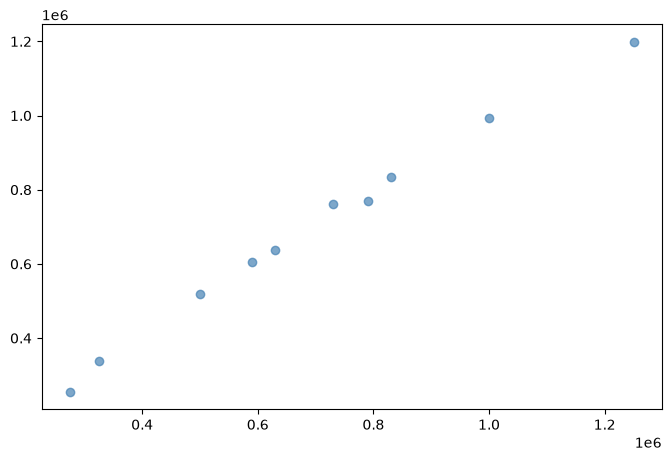

In [63]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7, label='Predicted vs Actual')
ideal_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(ideal_line, ideal_line, color='crimson', linewidth=2, linestyle='--', label='Ideal fit (y=x)')
plt.title('House Price Prediction: Actual vs Predicted')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
house = [[15, 2, 850]]
prediction = model.predict(house)

print(f'Estimated House price RS : {prediction}')

Estimated House price RS : [[158413.72428949]]


/media/dilan/New Volume/IJSE/4 Sem/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
